# Домашняя работа 1.2. Баллистическое движение в 2D
## квадратичное сопротивление

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
from base64 import b64encode
from PIL import Image as PILImage
from IPython.display import display, HTML, Markdown

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "font.size": 10,
                     "axes.grid": True, "grid.alpha": 0.25})

g = 9.81
mass = 1.0
v0 = 20.0
h_main = 0.01
k_values = [0.0, 0.01, 0.03, 0.07]
k_example = 0.03


def initial_state(angle):
    a = np.radians(angle)
    return np.array([0.0, 0.0, v0 * np.cos(a), v0 * np.sin(a)])


def rk4_step(state, h, f):
    k1 = f(state)
    k2 = f(state + h * k1 / 2)
    k3 = f(state + h * k2 / 2)
    k4 = f(state + h * k3)
    return state + h * (k1 + 2 * k2 + 2 * k3 + k4) / 6


def show_table(headers, rows):
    text = "| " + " | ".join(headers) + " |\n"
    text += "| " + " | ".join(["---"] * len(headers)) + " |\n"
    text += "\n".join("| " + " | ".join(map(str, row)) + " |" for row in rows)
    display(Markdown(text))


## 1. Проверка на линейной модели

Ось $y$ направлена вверх, состояние хранится как $(x,y,v_x,v_y)$.
При линейном сопротивлении ускорение равно $(0,-g)-\mathbf v/\tau$.
Если $q=1-\exp(-t/\tau)$, то при старте из начала координат

$$x=\tau v_{x0}q,\qquad y=\tau(v_{y0}+g\tau)q-g\tau t,$$
$$v_x=v_{x0}\exp(-t/\tau),\qquad
v_y=(v_{y0}+g\tau)\exp(-t/\tau)-g\tau.$$

Для проверки взяты угол 45°, $\tau=2$ с и четыре шага.
Оба метода считаются до одного и того же времени падения.
В таблице указана максимальная ошибка положения в узлах сетки.
Энергии: $U=mgy$, $K=m(v_x^2+v_y^2)/2$, $E=K+U$.


| Метод | h, с | Максимальная ошибка положения, м |
| --- | --- | --- |
| Эйлер | 0.2 | 1.4057e+00 |
| Эйлер | 0.1 | 6.8769e-01 |
| Эйлер | 0.05 | 3.4020e-01 |
| Эйлер | 0.025 | 1.6921e-01 |
| RK4 | 0.2 | 2.4396e-05 |
| RK4 | 0.1 | 1.4624e-06 |
| RK4 | 0.05 | 8.9515e-08 |
| RK4 | 0.025 | 5.5367e-09 |

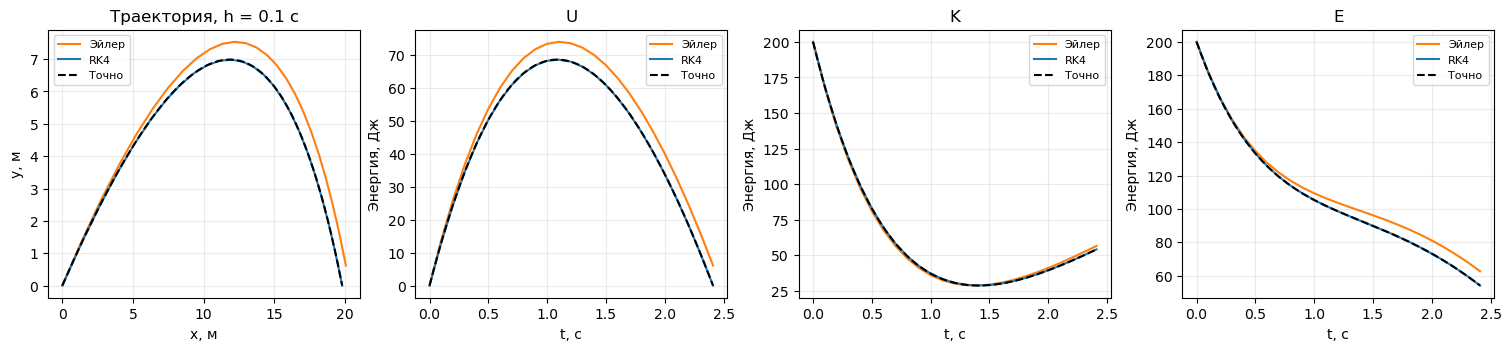

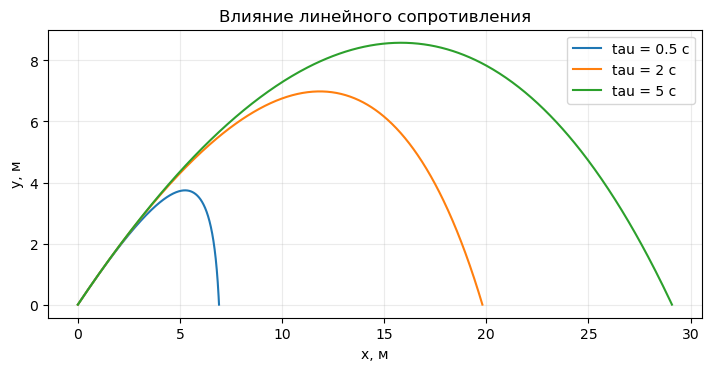

In [2]:
def linear_rhs(state, tau):
    x, y, vx, vy = state
    return np.array([vx, vy, -vx / tau, -g - vy / tau])


def linear_exact(t, angle, tau):
    t = np.atleast_1d(t)
    vx0, vy0 = initial_state(angle)[2:]
    q = -np.expm1(-t / tau)
    return np.column_stack((tau * vx0 * q,
                            tau * (vy0 + g * tau) * q - g * tau * t,
                            vx0 * (1 - q), (vy0 + g * tau) * (1 - q) - g * tau))


def linear_landing(angle, tau):
    vy0 = initial_state(angle)[3]
    left = tau * np.log1p(vy0 / (g * tau))
    right = max(1.0, 2 * left)
    while linear_exact(right, angle, tau)[0, 1] > 0:
        right *= 2
    for _ in range(45):
        middle = (left + right) / 2
        if linear_exact(middle, angle, tau)[0, 1] > 0:
            left = middle
        else:
            right = middle
    return (left + right) / 2


def linear_solution(angle, tau, h, method):
    t_end = linear_landing(angle, tau)
    t = np.minimum(np.arange(int(np.ceil(t_end / h)) + 1) * h, t_end)
    states = np.empty((len(t), 4))
    states[0] = initial_state(angle)
    f = lambda state: linear_rhs(state, tau)
    for i in range(len(t) - 1):
        dt = t[i + 1] - t[i]
        states[i + 1] = (states[i] + dt * f(states[i]) if method == "Эйлер"
                         else rk4_step(states[i], dt, f))
    return t, states


def energies(states):
    u = mass * g * states[:, 1]
    kinetic = mass * np.sum(states[:, 2:]**2, axis=1) / 2
    return u, kinetic, u + kinetic


linear_rows = []
for method in ["Эйлер", "RK4"]:
    for h in [0.2, 0.1, 0.05, 0.025]:
        t, states = linear_solution(45, 2, h, method)
        exact = linear_exact(t, 45, 2)
        error = np.max(np.linalg.norm(states[:, :2] - exact[:, :2], axis=1))
        linear_rows.append([method, h, f"{error:.4e}"])
show_table(["Метод", "h, с", "Максимальная ошибка положения, м"], linear_rows)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.4), layout="constrained")
for method, color in [("Эйлер", "tab:orange"), ("RK4", "tab:blue")]:
    t, states = linear_solution(45, 2, 0.1, method)
    axes[0].plot(states[:, 0], states[:, 1], color=color, label=method)
    for ax, values in zip(axes[1:], energies(states)):
        ax.plot(t, values, color=color, label=method)
t_exact = np.linspace(0, linear_landing(45, 2), 500)
exact = linear_exact(t_exact, 45, 2)
axes[0].plot(exact[:, 0], exact[:, 1], "k--", label="Точно")
axes[0].set(title="Траектория, h = 0.1 с", xlabel="x, м", ylabel="y, м")
for ax, values, title in zip(axes[1:], energies(exact), ["U", "K", "E"]):
    ax.plot(t_exact, values, "k--", label="Точно")
    ax.set(title=title, xlabel="t, с", ylabel="Энергия, Дж")
for ax in axes:
    ax.legend(fontsize=8)
plt.show()

fig, ax = plt.subplots(figsize=(7, 3.6), layout="constrained")
for tau in [0.5, 2.0, 5.0]:
    t = np.linspace(0, linear_landing(45, tau), 500)
    states = linear_exact(t, 45, tau)
    ax.plot(states[:, 0], states[:, 1], label=f"tau = {tau:g} с")
ax.set(title="Влияние линейного сопротивления", xlabel="x, м", ylabel="y, м")
ax.legend()
plt.show()


## 2. Квадратичное сопротивление и момент падения

Теперь ускорение имеет вид
$$\dot v_x=-k\sqrt{v_x^2+v_y^2}\,v_x,\qquad
\dot v_y=-g-k\sqrt{v_x^2+v_y^2}\,v_y.$$

Здесь $k$ измеряется в м$^{-1}$. В уравнении задан коэффициент при ускорении,
поэтому сила сопротивления равна $\mathbf F_с=-mk|\mathbf v|\mathbf v$.
При $k=0$ сопротивление отсутствует. Для численного решения используется RK4.

Если после очередного шага высота стала отрицательной, тело уже пересекло землю.
Последний узел нельзя считать точкой падения: ошибка дальности тогда зависит от того,
куда попала сетка. Поэтому в последнем интервале ищется длительность $\delta t$,
при которой высота после шага RK4 равна нулю. Поиск выполняется делением интервала
пополам, затем из того же состояния вычисляются время, координаты и скорость падения.
Это уточнение события в численном решении; оно не убирает накопленную ошибку RK4.

Углы перебора лежат между 1° и 89°, начальная высота и уровень земли равны нулю.


In [3]:
def quadratic_rhs(state, k):
    x, y, vx, vy = state
    speed = np.hypot(vx, vy)
    return np.array([vx, vy, -k * speed * vx, -g - k * speed * vy])


def locate_zero(state, h, f, component):
    left, right = 0.0, h
    for _ in range(40):
        middle = (left + right) / 2
        trial = rk4_step(state, middle, f)
        if trial[component] > 0:
            left = middle
        else:
            right = middle
    dt = (left + right) / 2
    return dt, rk4_step(state, dt, f)


def flight(angle, k, h=h_main):
    if not (0 < angle < 90 and k >= 0 and h > 0):
        raise ValueError("Нужны 0 < angle < 90, k >= 0 и h > 0.")
    f = lambda state: quadratic_rhs(state, k)
    times = [0.0]
    states = [initial_state(angle)]
    for _ in range(int(30 / h) + 1):
        new_state = rk4_step(states[-1], h, f)
        if new_state[1] <= 0 and new_state[3] < 0:
            dt, landing = locate_zero(states[-1], h, f, 1)
            assert abs(landing[1]) < 1e-8
            landing[1] = 0.0
            times.append(times[-1] + dt)
            states.append(landing)
            return np.array(times), np.array(states)
        times.append(times[-1] + h)
        states.append(new_state)
    raise RuntimeError("За 30 секунд падение не найдено.")


free_rows = []
for angle in [1, 15, 45, 75, 89]:
    t, states = flight(angle, 0, 0.08)
    a = np.radians(angle)
    exact_range = v0**2 * np.sin(2 * a) / g
    exact_time = 2 * v0 * np.sin(a) / g
    error = abs(states[-1, 0] - exact_range)
    assert error < 1e-8
    assert abs(t[-1] - exact_time) < 1e-9
    free_rows.append([angle, f"{states[-1, 0]:.8f}", f"{exact_range:.8f}", f"{error:.2e}"])
show_table(["Угол, °", "Расчётная дальность, м", "Точная дальность, м", "Ошибка, м"], free_rows)


| Угол, ° | Расчётная дальность, м | Точная дальность, м | Ошибка, м |
| --- | --- | --- | --- |
| 1 | 1.42301719 | 1.42301719 | 6.69e-13 |
| 15 | 20.38735984 | 20.38735984 | 6.68e-13 |
| 45 | 40.77471967 | 40.77471967 | 1.21e-13 |
| 75 | 20.38735984 | 20.38735984 | 5.33e-14 |
| 89 | 1.42301719 | 1.42301719 | 2.22e-16 |

## 3. Перебор углов

Для каждого k сначала перебираются углы от 1° до 89° с шагом 1°.
Затем в окрестности найденного максимума, в пределах ±1°, выполняется второй перебор
с шагом 0.02°.
Таким образом, найден лучший угол на сетке, а не точный непрерывный максимум.

При отсутствии сопротивления $R=v_0^2\sin(2\alpha)/g$, и максимум должен находиться при 45°.
На графике кружками отмечены максимумы после уточнения угловой сетки.


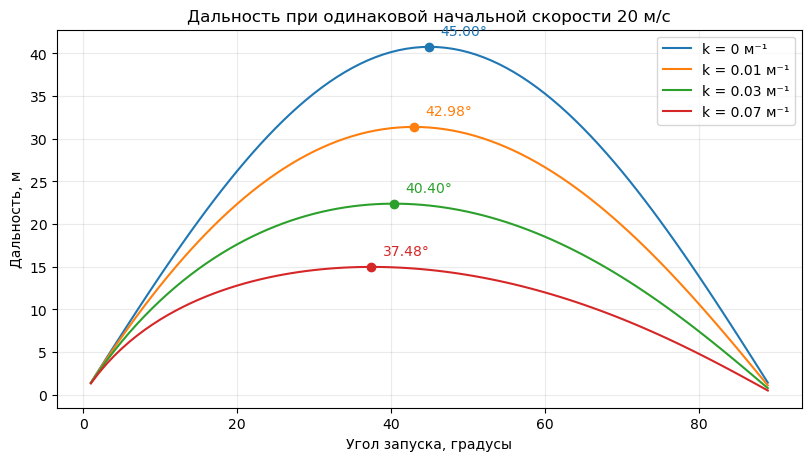

| k, м⁻¹ | Лучший угол сетки, ° | Максимальная дальность, м |
| --- | --- | --- |
| 0.0 | 45.00 | 40.774720 |
| 0.01 | 42.98 | 31.391472 |
| 0.03 | 40.40 | 22.398672 |
| 0.07 | 37.48 | 14.987275 |

In [4]:
angles = np.arange(1.0, 90.0, 1.0)


def scan_angles(k, h, angle_step=0.02):
    ranges = np.array([flight(angle, k, h)[1][-1, 0] for angle in angles])
    best = angles[np.argmax(ranges)]
    left = max(1.0, best - 1.0)
    right = min(89.0, best + 1.0)
    fine_angles = np.arange(left, right + angle_step / 2, angle_step)
    fine_ranges = np.array([flight(angle, k, h)[1][-1, 0] for angle in fine_angles])
    j = np.argmax(fine_ranges)
    return ranges, float(fine_angles[j]), float(fine_ranges[j])


maxima = {}
range_curves = {}
fig, ax = plt.subplots(figsize=(8, 4.5), layout="constrained")
for k in k_values:
    ranges, best_angle, best_range = scan_angles(k, h_main)
    maxima[k] = (best_angle, best_range)
    range_curves[k] = ranges
    line, = ax.plot(angles, ranges, label=f"k = {k:g} м⁻¹")
    ax.plot(best_angle, best_range, "o", color=line.get_color())
    ax.annotate(f"{best_angle:.2f}°", (best_angle, best_range),
                xytext=(8, 8), textcoords="offset points", color=line.get_color())
ax.set(xlabel="Угол запуска, градусы", ylabel="Дальность, м",
       title="Дальность при одинаковой начальной скорости 20 м/с")
ax.legend()
plt.show()
show_table(["k, м⁻¹", "Лучший угол сетки, °", "Максимальная дальность, м"],
           [[k, f"{a:.2f}", f"{r:.6f}"] for k, (a, r) in maxima.items()])
assert abs(maxima[0.0][0] - 45.0) < 1e-8


## 4. Проверка шага времени и шага по углу

Сначала повторяется поиск максимума для всех четырёх коэффициентов на шагах
0.08, 0.04, 0.02 и 0.01 с. Разность $\Delta R$ считается относительно предыдущей,
более грубой сетки. Равенство лучших углов означает только, что изменение меньше
разрешения перебора в 0.02°.

Затем при фиксированном угле 40° и $k=0.03$ сравнивается дальность с расчётом
на шаге 0.00125 с. Это более подробный численный расчёт, а не точное решение.
Наконец отдельно меняется шаг перебора углов при неизменном шаге времени.


In [5]:
convergence = []
step_changes = []
for k in k_values:
    previous = None
    for h in [0.08, 0.04, 0.02, 0.01]:
        if h == h_main:
            best_angle, best_range = maxima[k]
        else:
            _, best_angle, best_range = scan_angles(k, h)
        change = None if previous is None else abs(best_range - previous)
        convergence.append([k, h, f"{best_angle:.2f}", f"{best_range:.8f}",
                            "—" if change is None else f"{change:.3e}"])
        if h == h_main:
            step_changes.append(change)
        previous = best_range
show_table(["k, м⁻¹", "h, с", "Угол, °", "R_max, м", "Изменение R_max, м"], convergence)

reference_range = flight(40, k_example, 0.00125)[1][-1, 0]
fixed_errors = []
fixed_rows = []
for h in [0.08, 0.04, 0.02, 0.01]:
    t, states = flight(40, k_example, h)
    error = abs(states[-1, 0] - reference_range)
    fixed_errors.append(error)
    fixed_rows.append([h, f"{t[-1]:.9f}", f"{states[-1, 0]:.9f}", f"{error:.3e}"])
show_table(["h, с", "Время падения при 40°, с", "Дальность при 40°, м", "Ошибка к подробному расчёту, м"], fixed_rows)
assert fixed_errors[-1] < fixed_errors[0]
observed_order = np.log2(fixed_errors[-2] / fixed_errors[-1])
print(f"Оценка порядка по двум мелким шагам: {observed_order:.2f}")

angular_rows = []
coarse_best = angles[np.argmax(range_curves[k_example])]
for angle_step in [1.0, 0.2, 0.1, 0.02]:
    fine = np.arange(coarse_best - 1, coarse_best + 1 + angle_step / 2, angle_step)
    distances = [flight(angle, k_example, h_main)[1][-1, 0] for angle in fine]
    j = np.argmax(distances)
    angular_rows.append([angle_step, f"{fine[j]:.2f}", f"{distances[j]:.8f}"])
show_table(["Шаг по углу, °", "Лучший угол при k=0.03, °", "Дальность, м"], angular_rows)


| k, м⁻¹ | h, с | Угол, ° | R_max, м | Изменение R_max, м |
| --- | --- | --- | --- | --- |
| 0.0 | 0.08 | 45.00 | 40.77471967 | — |
| 0.0 | 0.04 | 45.00 | 40.77471967 | 2.558e-13 |
| 0.0 | 0.02 | 45.00 | 40.77471967 | 1.350e-13 |
| 0.0 | 0.01 | 45.00 | 40.77471967 | 1.990e-13 |
| 0.01 | 0.08 | 42.98 | 31.39147161 | — |
| 0.01 | 0.04 | 42.98 | 31.39147193 | 3.162e-07 |
| 0.01 | 0.02 | 42.98 | 31.39147195 | 1.939e-08 |
| 0.01 | 0.01 | 42.98 | 31.39147195 | 1.202e-09 |
| 0.03 | 0.08 | 40.40 | 22.39866698 | — |
| 0.03 | 0.04 | 40.40 | 22.39867208 | 5.106e-06 |
| 0.03 | 0.02 | 40.40 | 22.39867239 | 3.040e-07 |
| 0.03 | 0.01 | 40.40 | 22.39867240 | 1.853e-08 |
| 0.07 | 0.08 | 37.48 | 14.98722005 | — |
| 0.07 | 0.04 | 37.48 | 14.98727161 | 5.157e-05 |
| 0.07 | 0.02 | 37.48 | 14.98727450 | 2.886e-06 |
| 0.07 | 0.01 | 37.48 | 14.98727467 | 1.703e-07 |

| h, с | Время падения при 40°, с | Дальность при 40°, м | Ошибка к подробному расчёту, м |
| --- | --- | --- | --- |
| 0.08 | 2.194935271 | 22.397041832 | 5.463e-06 |
| 0.04 | 2.194935686 | 22.397046969 | 3.257e-07 |
| 0.02 | 2.194935711 | 22.397047275 | 1.987e-08 |
| 0.01 | 2.194935712 | 22.397047293 | 1.227e-09 |

Оценка порядка по двум мелким шагам: 4.02


| Шаг по углу, ° | Лучший угол при k=0.03, ° | Дальность, м |
| --- | --- | --- |
| 1.0 | 40.00 | 22.39704729 |
| 0.2 | 40.40 | 22.39867240 |
| 0.1 | 40.40 | 22.39867240 |
| 0.02 | 40.40 | 22.39867240 |

## 5. Симметрия траектории

Для сравнения формы выбран один угол запуска, 45°. Вершина уточняется внутри шага
по условию $v_y=0$ тем же делением пополам. На графиках дополнительно показано
зеркальное отражение траектории относительно прямой $x=R/2$.
У симметричной траектории отражённая кривая совпадает с исходной.

В таблице сравниваются времена подъёма и спуска, положение вершины и угол падения.
Угол падения указан положительным числом относительно горизонтали.


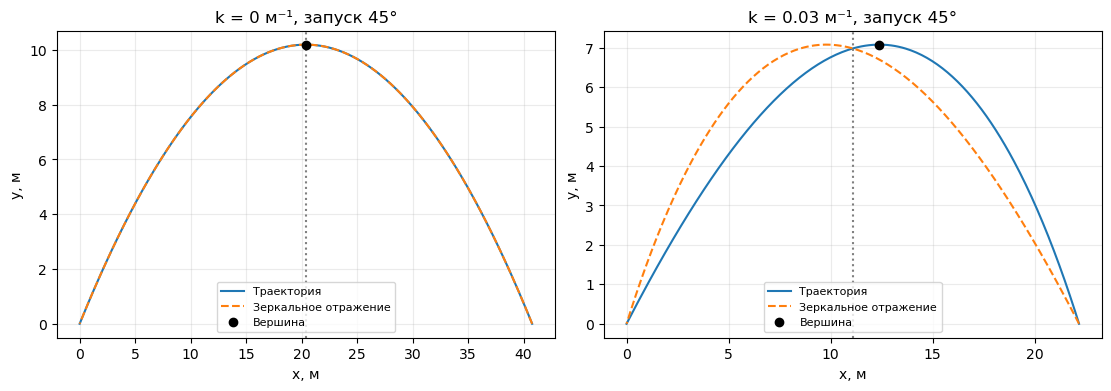

| k, м⁻¹ | Подъём, с | Спуск, с | x_вершины / R | Угол падения, ° |
| --- | --- | --- | --- | --- |
| 0.0 | 1.4416 | 1.4416 | 0.5000 | 45.00 |
| 0.03 | 1.1152 | 1.2759 | 0.5587 | 58.80 |

In [6]:
def apex_of_flight(t, states, k):
    j = np.flatnonzero((states[:-1, 3] > 0) & (states[1:, 3] <= 0))[0]
    f = lambda state: quadratic_rhs(state, k)
    dt, apex = locate_zero(states[j], t[j + 1] - t[j], f, 3)
    return t[j] + dt, apex


symmetry = {}
symmetry_rows = []
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), layout="constrained")
for ax, k in zip(axes, [0.0, k_example]):
    t, states = flight(45, k, h_main)
    up_time, apex = apex_of_flight(t, states, k)
    down_time = t[-1] - up_time
    distance = states[-1, 0]
    apex_fraction = apex[0] / distance
    landing_angle = np.degrees(np.arctan2(-states[-1, 3], states[-1, 2]))
    symmetry[k] = (up_time, down_time, apex_fraction, landing_angle)
    symmetry_rows.append([k, f"{up_time:.4f}", f"{down_time:.4f}",
                          f"{apex_fraction:.4f}", f"{landing_angle:.2f}"])
    ax.plot(states[:, 0], states[:, 1], label="Траектория")
    ax.plot(distance - states[:, 0], states[:, 1], "--", label="Зеркальное отражение")
    ax.axvline(distance / 2, color="gray", linestyle=":")
    ax.plot(apex[0], apex[1], "ko", label="Вершина")
    ax.set(title=f"k = {k:g} м⁻¹, запуск 45°", xlabel="x, м", ylabel="y, м")
    ax.legend(fontsize=8)
plt.show()
show_table(["k, м⁻¹", "Подъём, с", "Спуск, с", "x_вершины / R", "Угол падения, °"], symmetry_rows)

t_example, states_example = flight(45, k_example, h_main)
energy = energies(states_example)[2]
assert np.max(np.diff(energy)) < 1e-8


## 6. Анимация одного полёта: скорость и силы

Показан запуск под 45° при $k=0.03$ м$^{-1}$.
Синий след показывает пройденную траекторию; стрелки начинаются в положении тела.
Сила тяжести постоянна и направлена вниз, сила сопротивления направлена против скорости.

Для скорости и сил использованы разные постоянные масштабы:
0.15 м рисунка на 1 м/с и 0.30 м рисунка на 1 Н.
Поэтому длины стрелок скорости и силы между собой не сравниваются.
У двух сил масштаб одинаковый. После касания земли стрелки скрываются: удар не моделируется.

Для плавности кадры интерполируются по общей временной сетке.
Эта интерполяция используется только в рисунке; дальность и время падения выше
получены из уточнённого последнего шага RK4.


Анимации ниже выводятся как встроенные GIF и повторяются автоматически. JavaScript и отдельные файлы не нужны.


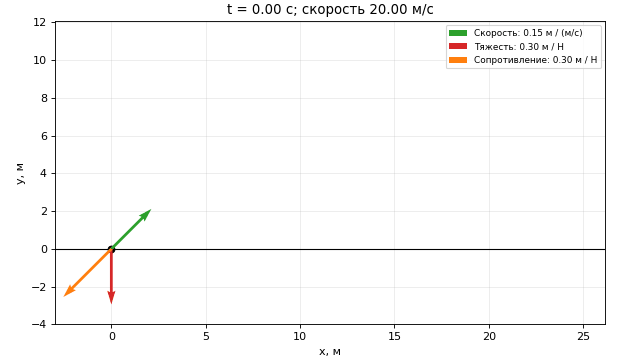

In [7]:
def show_animation(fig, update, frame_count):
    frames = []
    for i in range(frame_count):
        update(i)
        fig.canvas.draw()
        frame = PILImage.fromarray(np.asarray(fig.canvas.buffer_rgba())).convert("RGB")
        frames.append(frame)

    # GIF собирается в памяти и отображается прямо в ячейке.
    buffer = BytesIO()
    frames[0].save(buffer, format="GIF", save_all=True, append_images=frames[1:],
                   duration=50, loop=0)
    plt.close(fig)
    data = b64encode(buffer.getvalue()).decode("ascii")
    display(HTML(f'<img alt="Анимация полёта" src="data:image/gif;base64,{data}">'))


def sample_flight(t, states, times):
    return np.column_stack([np.interp(times, t, states[:, j]) for j in range(4)])


single_times = np.linspace(0, t_example[-1] + 0.35, 96)
single_motion = sample_flight(t_example, states_example, single_times)
fig_single, ax_single = plt.subplots(figsize=(8, 4.5), dpi=80, layout="constrained")
single_trail, = ax_single.plot([], [], color="tab:blue", linewidth=1.5)
single_body, = ax_single.plot([], [], "ko", markersize=6)
single_arrows = []
for color, label in [("tab:green", "Скорость: 0.15 м / (м/с)"),
                     ("tab:red", "Тяжесть: 0.30 м / Н"),
                     ("tab:orange", "Сопротивление: 0.30 м / Н")]:
    arrow = ax_single.quiver([0], [0], [0], [0], angles="xy", scale_units="xy",
                             scale=1, color=color, label=label, width=0.005, zorder=4)
    single_arrows.append(arrow)
ax_single.axhline(0, color="black", linewidth=1)
ax_single.set(xlim=(-3, states_example[-1, 0] + 4),
              ylim=(-4, states_example[:, 1].max() + 5),
              aspect="equal", xlabel="x, м", ylabel="y, м")
ax_single.legend(loc="upper right", fontsize=8)
single_title = ax_single.set_title("")


def update_single(frame):
    state = single_motion[frame]
    v = state[2:]
    landed = single_times[frame] >= t_example[-1]
    vectors = [0.15 * v,
               0.30 * np.array([0.0, -mass * g]),
               -0.30 * mass * k_example * np.linalg.norm(v) * v]
    single_trail.set_data(single_motion[:frame + 1, 0], single_motion[:frame + 1, 1])
    single_body.set_data([state[0]], [state[1]])
    for arrow, vector in zip(single_arrows, vectors):
        arrow.set_offsets(state[:2].reshape(1, 2))
        arrow.set_UVC([vector[0]], [vector[1]])
        arrow.set_visible(not landed)
    status = "касание земли" if landed else f"скорость {np.linalg.norm(v):.2f} м/с"
    single_title.set_text(f"t = {single_times[frame]:.2f} с; {status}")


show_animation(fig_single, update_single, len(single_times))


## 7. Одновременный запуск десяти тел

Углы: от 10° до 82° с шагом 8°. Все тела стартуют из одной точки при $t=0$
с одинаковым модулем скорости 20 м/с. Слева сопротивления нет, справа $k=0.03$ м$^{-1}$.
Для обеих панелей используется одно физическое время, одинаковые пределы осей и одинаковый масштаб.
Цвет одного угла на обеих панелях совпадает.

После приземления движущаяся точка исчезает, а на земле остаётся крестик.
След больше не растёт. Время анимации продолжается, пока не упадёт последнее тело.



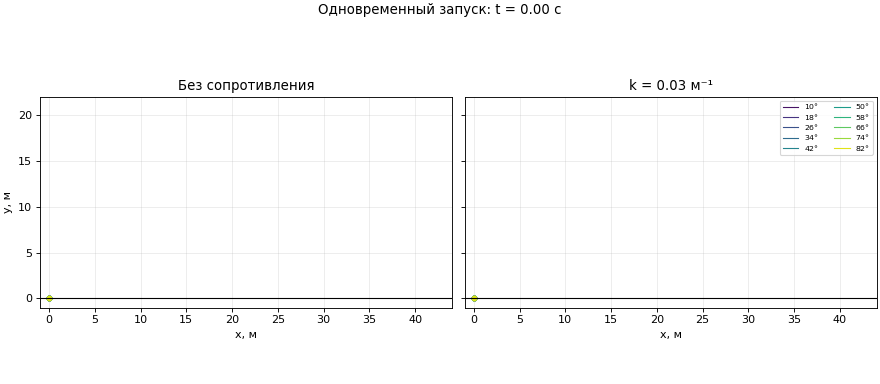

In [8]:
launch_angles = np.arange(10.0, 83.0, 8.0)
launch_colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(launch_angles)))
ensemble_flights = [[flight(angle, k, h_main) for angle in launch_angles]
                   for k in [0.0, k_example]]
last_landing = max(t[-1] for panel in ensemble_flights for t, states in panel)
ensemble_times = np.linspace(0, last_landing + 0.4, 121)
ensemble_motion = [[sample_flight(t, states, ensemble_times) for t, states in panel]
                   for panel in ensemble_flights]

fig_ensemble, ensemble_axes = plt.subplots(1, 2, figsize=(11, 4.8), dpi=80,
                                          sharex=True, sharey=True, layout="constrained")
ensemble_artists = []
for ax, k in zip(ensemble_axes, [0.0, k_example]):
    group = []
    for angle, color in zip(launch_angles, launch_colors):
        trail, = ax.plot([], [], color=color, linewidth=1, label=f"{angle:g}°")
        body, = ax.plot([], [], "o", color=color, markersize=4)
        mark, = ax.plot([], [], "x", color=color, markersize=7, markeredgewidth=1.6)
        group.append((trail, body, mark))
    ensemble_artists.append(group)
    ax.set(xlim=(-1, 44), ylim=(-1, 22), aspect="equal", xlabel="x, м",
           title="Без сопротивления" if k == 0 else f"k = {k:g} м⁻¹")
    ax.axhline(0, color="black", linewidth=1)
ensemble_axes[0].set_ylabel("y, м")
ensemble_axes[1].legend(ncol=2, fontsize=7, loc="upper right")
ensemble_title = fig_ensemble.suptitle("")


def update_ensemble(frame):
    now = ensemble_times[frame]
    for panel in range(2):
        for i, (trail, body, mark) in enumerate(ensemble_artists[panel]):
            t, states = ensemble_flights[panel][i]
            motion = ensemble_motion[panel][i]
            trail.set_data(motion[:frame + 1, 0], motion[:frame + 1, 1])
            if now >= t[-1]:
                body.set_data([], [])
                mark.set_data([states[-1, 0]], [0.0])
            else:
                body.set_data([motion[frame, 0]], [motion[frame, 1]])
                mark.set_data([], [])
    ensemble_title.set_text(f"Одновременный запуск: t = {now:.2f} с")


show_animation(fig_ensemble, update_ensemble, len(ensemble_times))


## 8. Что получилось

Следующая ячейка подставляет в выводы результаты выполненных расчётов.
При изменении параметров нужно повторно выполнить все предыдущие ячейки.


In [9]:
up, down, fraction, impact_angle = symmetry[k_example]
best_angle, best_range = maxima[k_example]
display(Markdown(
    f"При **k = 0** максимум находится при **{maxima[0.0][0]:.2f}°**, "
    f"дальность равна **{maxima[0.0][1]:.3f} м**. "
    f"Это совпадает с формулой свободного броска.\n\n"
    f"При **k = {k_example:g} м⁻¹** лучший угол сетки равен **{best_angle:.2f}°**, "
    f"дальность — **{best_range:.3f} м**. "
    f"При самом большом из выбранных коэффициентов, k = {k_values[-1]:g} м⁻¹, "
    f"угол уменьшается до **{maxima[k_values[-1]][0]:.2f}°**. "
    "В рассмотренном диапазоне рост сопротивления уменьшает дальность и оптимальный угол. "
    "Более высокий запуск увеличивает время, за которое сопротивление успевает "
    "уменьшить горизонтальную скорость. Поэтому максимум смещается ниже 45°.\n\n"
    f"При запуске под 45° и k = {k_example:g} подъём длится **{up:.3f} с**, "
    f"спуск — **{down:.3f} с**. Вершина находится на **{100*fraction:.1f}% дальности**, "
    f"а угол падения равен **{impact_angle:.1f}°**. "
    "Вершина смещена дальше середины дальности, нисходящая ветвь круче восходящей. "
    "Траектория теряет зеркальную симметрию: горизонтальная скорость непрерывно "
    "убывает, а при падении модуль скорости меньше начального.\n\n"
    f"При уменьшении шага с 0.02 до 0.01 с наибольшее изменение максимальной "
    f"дальности среди выбранных k составило **{max(step_changes):.2e} м**. "
    f"Для фиксированного угла оценка порядка RK4 равна **{observed_order:.2f}**. "
    "Шаг времени 0.01 с достаточен для приведённых значений дальности, округлённых "
    "до миллиметров. Оптимальные углы указаны с разрешением перебора **0.02°**; "
    "одна только неизменность угла на сетке не означала бы точного нахождения максимума."
))


При **k = 0** максимум находится при **45.00°**, дальность равна **40.775 м**. Это совпадает с формулой свободного броска.

При **k = 0.03 м⁻¹** лучший угол сетки равен **40.40°**, дальность — **22.399 м**. При самом большом из выбранных коэффициентов, k = 0.07 м⁻¹, угол уменьшается до **37.48°**. В рассмотренном диапазоне рост сопротивления уменьшает дальность и оптимальный угол. Более высокий запуск увеличивает время, за которое сопротивление успевает уменьшить горизонтальную скорость. Поэтому максимум смещается ниже 45°.

При запуске под 45° и k = 0.03 подъём длится **1.115 с**, спуск — **1.276 с**. Вершина находится на **55.9% дальности**, а угол падения равен **58.8°**. Вершина смещена дальше середины дальности, нисходящая ветвь круче восходящей. Траектория теряет зеркальную симметрию: горизонтальная скорость непрерывно убывает, а при падении модуль скорости меньше начального.

При уменьшении шага с 0.02 до 0.01 с наибольшее изменение максимальной дальности среди выбранных k составило **1.70e-07 м**. Для фиксированного угла оценка порядка RK4 равна **4.02**. Шаг времени 0.01 с достаточен для приведённых значений дальности, округлённых до миллиметров. Оптимальные углы указаны с разрешением перебора **0.02°**; одна только неизменность угла на сетке не означала бы точного нахождения максимума.